<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Chapter_1_Fundamentals_of_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter 1: Fundamentals of Forecasting**

## What is Forecasting?

Forecasting is the process of predicting future values using historical data and available information. It helps in understanding future trends and supports decision-making.

## Objective

The objective of this assignment is to understand the basic concepts of forecasting and apply a forecasting model on temperature data.

In this project, a temperature time series dataset is generated, analyzed, and used to predict future temperature values using the Holt-Winters Exponential Smoothing method.

# **Step 1: Import Libraries**

This step imports the required Python libraries for data analysis, visualization, and forecasting.

- NumPy is used for numerical computations.
- Pandas is used for creating and managing datasets.
- Matplotlib is used for data visualization.
- ExponentialSmoothing is used to build the forecasting model.

A random seed is set to ensure reproducible results.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(42)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# **Step 2: Generate Temperature Dataset**

In this step, a temperature time series dataset is generated for 48 months from January 2022 to December 2025.

The dataset consists of three components:

- **Trend:** Represents the gradual increase in temperature over time.
- **Seasonality:** Represents recurring yearly temperature patterns.
- **Noise:** Represents random variations in temperature.

These components are combined to create a realistic temperature dataset for forecasting analysis.

In [3]:
months = pd.date_range(
    start='2022-01-01',
    periods=48,
    freq='ME'
)

trend = 0.03 * np.arange(48) + 28

seasonality = 4 * np.sin(
    2 * np.pi * months.month / 12
)

noise = np.random.normal(
    0,
    0.8,
    48
)

temperature = trend + seasonality + noise

df = pd.DataFrame(
    {'Temperature': temperature},
    index=months
)

df.head()

,Temperature
2022-01-31,30.397371
2022-02-28,31.383490
2022-03-31,32.578151
2022-04-30,32.772526
2022-05-31,29.932677


# **Step 3: Display Dataset Information**

This step examines the structure and statistical summary of the temperature dataset using `info()` and `describe()`.

### Result

The dataset contains **48 temperature records** and **1 column**. All values are present with **no missing data**. The average temperature is **28.54°C**, with values ranging from **23.86°C to 32.79°C**. This confirms that the dataset is complete, consistent, and ready for forecasting analysis.

In [4]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (48, 1)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2022-01-31 to 2025-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


,Temperature
count,48.000000
mean,28.540762
std,2.767829
min,23.864420
25%,25.900345
50%,28.354985
75%,31.014791
max,32.791591


# **Step 4: View First 10 Records**

This step displays the first 10 records of the temperature dataset using `df.head(10)`. It helps us verify that the data has been generated correctly and is arranged in chronological order.

### Result

The output shows the first 10 monthly temperature observations from January 2022 onwards. The temperature values vary across months, indicating seasonal changes and natural fluctuations in the dataset.

In [5]:
df.head(10)

,Temperature
2022-01-31,30.397371
2022-02-28,31.383490
2022-03-31,32.578151
2022-04-30,32.772526
2022-05-31,29.932677
2022-06-30,27.962690
2022-07-31,27.443370
2022-08-31,25.359846
2022-09-30,23.864420
2022-10-31,25.239946


# **Step 5: Exploratory Data Analysis (EDA)**

This step visualizes the temperature data using a line graph. Data visualization helps identify important patterns such as trends, seasonality, and fluctuations over time.

### Result

The graph shows a clear seasonal pattern, with temperatures rising and falling at regular intervals each year. Temperature values fluctuate between approximately **24°C and 33°C**, indicating recurring seasonal changes. This pattern suggests that the dataset is suitable for time series forecasting.

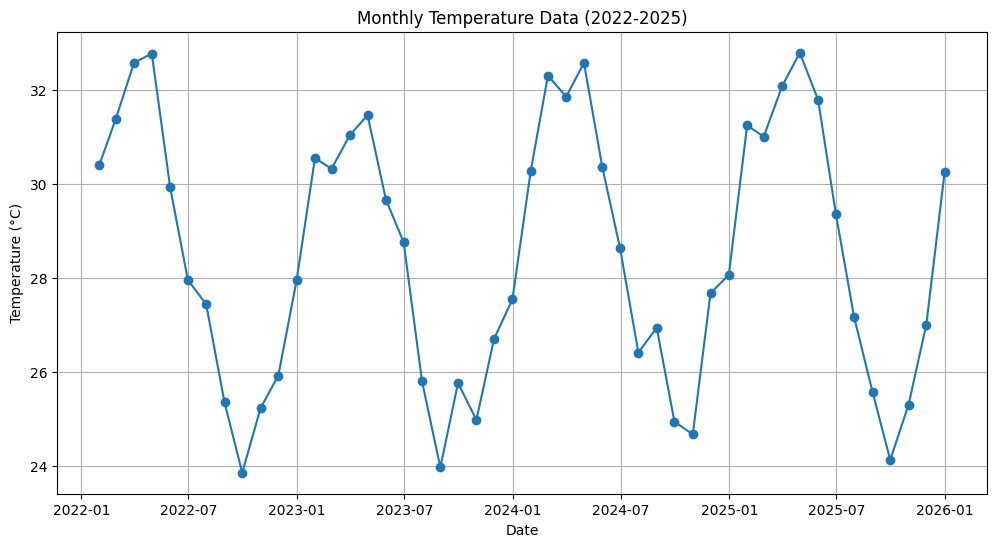

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df['Temperature'],
    marker='o'
)

plt.title("Monthly Temperature Data (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

# **Step 6: Split Dataset into Training and Testing Data**

This step divides the dataset into training and testing sets. The training data is used to build the forecasting model, while the testing data is used to evaluate its performance on unseen observations.

### Result

The dataset was successfully split into **36 training records** and **12 testing records**. The training data contains historical temperature observations used for model learning, while the testing data represents the final 12 months used for forecast validation.

In [7]:
train_df = df.iloc[:-12]

test_df = df.iloc[-12:]

print("Training Data Shape:", train_df.shape)

print("Testing Data Shape:", test_df.shape)

Training Data Shape: (36, 1)
Testing Data Shape: (12, 1)


# **Step 7: Build the Forecasting Model**

In this step, the Holt-Winters Exponential Smoothing model is trained using the temperature data from the training dataset. This model is capable of capturing both trend and seasonal patterns present in the data.

### Result

The model was successfully trained on **36 temperature observations**. The summary output confirms that an additive trend and additive seasonal model with a seasonal period of **12 months** was fitted. The optimized parameters indicate that the model has learned the underlying patterns in the dataset and is ready to generate future temperature forecasts.

In [8]:
model = ExponentialSmoothing(
    train_df['Temperature'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

print(model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:              Temperature   No. Observations:                   36
Model:             ExponentialSmoothing   SSE                             14.899
Optimized:                         True   AIC                              0.240
Trend:                         Additive   BIC                             25.576
Seasonal:                      Additive   AICC                            40.475
Seasonal Periods:                    12   Date:                 Sun, 21 Jun 2026
Box-Cox:                          False   Time:                         08:50:37
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1694311                alpha                 True
smoothing_trend          

# **Step 8: Generate Temperature Forecasts**

In this step, the trained Holt-Winters model is used to forecast temperature values for the next 12 months. These forecasted values represent the model's predictions based on the historical patterns learned from the training data.

### Result

The model successfully generated temperature forecasts for the year **2025**. The predicted temperatures range from approximately **25.93°C to 33.12°C**, showing seasonal fluctuations throughout the year. These forecasts represent the expected future temperatures based on the trend and seasonality observed in the historical dataset.

In [9]:
forecast = model.forecast(12)

forecast

,0
2025-01-31,31.087198
2025-02-28,32.072152
2025-03-31,32.618357
2025-04-30,33.116826
2025-05-31,30.884241
2025-06-30,29.397893
2025-07-31,27.546958
2025-08-31,26.457262
2025-09-30,25.929089
2025-10-31,26.069825


# **Step 9: Calculate Prediction Intervals**

In this step, prediction intervals are calculated for each forecasted temperature value. The lower and upper bounds provide a range within which the actual future temperature is expected to lie with a high level of confidence.

### Result

The output displays the forecasted temperature along with its corresponding lower and upper prediction bounds. For example, the forecasted temperature for **January 2025** is **31.09°C**, with an expected range of approximately **29.85°C to 32.33°C**. These intervals help measure the uncertainty associated with future predictions and provide a more reliable forecasting analysis.

In [10]:
residual_std = np.std(model.resid)

lower_bound = forecast - 1.96 * residual_std

upper_bound = forecast + 1.96 * residual_std

prediction_df = pd.DataFrame({
    "Forecast": forecast,
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

prediction_df

,Forecast,Lower Bound,Upper Bound
2025-01-31,31.087198,29.845647,32.328749
2025-02-28,32.072152,30.830601,33.313703
2025-03-31,32.618357,31.376806,33.859908
2025-04-30,33.116826,31.875275,34.358377
2025-05-31,30.884241,29.642690,32.125792
2025-06-30,29.397893,28.156342,30.639444
2025-07-31,27.546958,26.305407,28.788509
2025-08-31,26.457262,25.215711,27.698813
2025-09-30,25.929089,24.687538,27.170639
2025-10-31,26.069825,24.828274,27.311376


# **Step 10: Visualize Forecast Results**

In this step, the forecasted temperatures are compared with the actual temperature values using a line graph. The graph also displays the 95% prediction interval, which represents the expected range of future temperature values.

### Result

The graph shows that the forecasted temperatures closely follow the actual temperature pattern. Most of the actual values fall within the 95% prediction interval, indicating that the model is able to capture the seasonal behavior of the dataset effectively. This suggests that the Holt-Winters model provides reliable temperature forecasts.

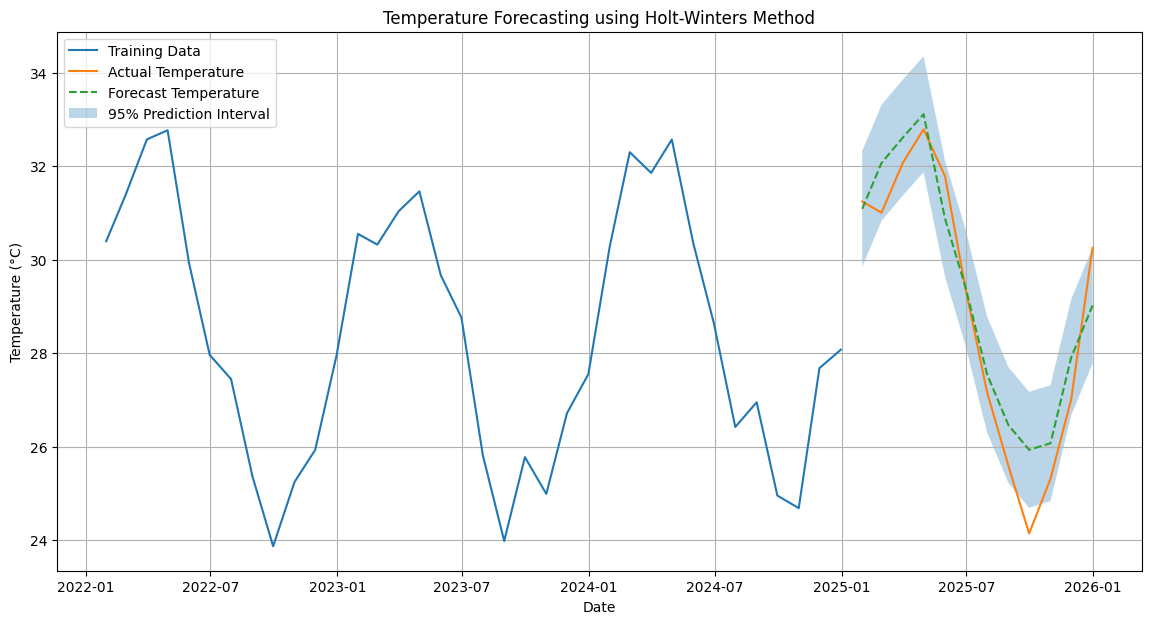

In [11]:
forecast_dates = test_df.index

plt.figure(figsize=(14,7))

plt.plot(
    train_df.index,
    train_df['Temperature'],
    label='Training Data'
)

plt.plot(
    test_df.index,
    test_df['Temperature'],
    label='Actual Temperature'
)

plt.plot(
    forecast_dates,
    forecast,
    linestyle='--',
    label='Forecast Temperature'
)

plt.fill_between(
    forecast_dates,
    lower_bound,
    upper_bound,
    alpha=0.3,
    label='95% Prediction Interval'
)

plt.title("Temperature Forecasting using Holt-Winters Method")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()

# **Step 11: Evaluate Model Performance**

In this step, the forecasting model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics measure the difference between the actual and forecasted temperature values.

### Result

The model achieved an **MAE of 0.75** and an **RMSE of 0.89**. These low error values indicate that the forecasted temperatures are very close to the actual temperatures. Therefore, the Holt-Winters model demonstrates good forecasting accuracy for this dataset.

In [12]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    test_df['Temperature'],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test_df['Temperature'],
        forecast
    )
)

print("Mean Absolute Error (MAE):", round(mae,2))

print("Root Mean Squared Error (RMSE):", round(rmse,2))

Mean Absolute Error (MAE): 0.75
Root Mean Squared Error (RMSE): 0.89


# **Step 12: Forecast Future Temperatures for 2026**

In this step, the trained Holt-Winters model is used to predict monthly temperatures for the year 2026. These forecasts are based on the historical trend and seasonal patterns learned from the dataset.

### Result

The model successfully generated temperature forecasts for all 12 months of 2026. The predicted temperatures range from approximately **25.93°C to 33.12°C**. The forecast indicates that temperature patterns in 2026 are expected to follow a similar seasonal cycle as observed in previous years, with higher temperatures during certain months and lower temperatures during others.

In [14]:
future_forecast = model.forecast(12)

future_dates = pd.date_range(
    start='2026-01-31',
    periods=12,
    freq='ME'
)

future_df = pd.DataFrame({
    "Forecasted Temperature": future_forecast.values
}, index=future_dates)

future_df

,Forecasted Temperature
2026-01-31,31.087198
2026-02-28,32.072152
2026-03-31,32.618357
2026-04-30,33.116826
2026-05-31,30.884241
2026-06-30,29.397893
2026-07-31,27.546958
2026-08-31,26.457262
2026-09-30,25.929089
2026-10-31,26.069825
